# traQmania 03 — Quantum circuits as Q-functions

The [previous notebook](02_q_learning_from_scratch.ipynb) trained a 76-parameter
MLP with double DQN. Here we swap the network for a **variational quantum
circuit (VQC)**: a parameterized circuit whose expectation values act as the
function approximator, with the classical optimizer training its angles.

Using VQCs as Q-functions goes back to
[Chen et al., *Variational Quantum Circuits for Deep Reinforcement Learning*,
IEEE Access 2020](https://research.ibm.com/publications/variational-quantum-circuits-for-deep-reinforcement-learning)
(an IBM Research work). Our architecture additionally uses **data
re-uploading** with trainable input scaling, following
[Skolik, Jerbi & Dunjko, *Quantum agents in the Gym*, Quantum 6, 720 (2022)](https://quantum-journal.org/papers/q-2022-05-24-720/)
and [Pérez-Salinas et al., Quantum 4, 226 (2020)](https://quantum-journal.org/papers/q-2020-02-06-226/);
for a broad overview see the survey by
[Meyer et al., *A Survey on Quantum Reinforcement Learning* (arXiv:2211.03464)](https://arxiv.org/abs/2211.03464).

## The circuit

4 qubits (one per observation feature), and $L = 4$ blocks, each consisting of:

1. **encoding**: $RY(\lambda_{l,i} \cdot s_i)$ on qubit $i$ — the observation
   is re-uploaded in *every* block, with a trainable scale $\lambda_{l,i}$
2. **variational**: $RY(\theta_{l,i,0})\, RZ(\theta_{l,i,1})$ on each qubit
3. **entangling**: a ring of CZ gates

Readout is one expectation per action, $E_a = \langle Z_a \rangle \in [-1, 1]$,
mapped to a Q-value by a classical head $Q_a = w_a E_a + b_a$ (Q-values on this
task reach the hundreds, so a trainable output scale is essential — see Skolik
et al. for why).

In [1]:
# On Binder (QuBins images) this repo arrives via nbgitpuller without being
# pip-installed; install it from GitHub only if the import fails.
try:
    import traqmania  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/JanLahmann/traQmania

import matplotlib.pyplot as plt
import numpy as np

gates: 64  |  trainable parameters: {'lam': 16, 'theta': 32, 'w': 4, 'b': 4, 'total': 56}


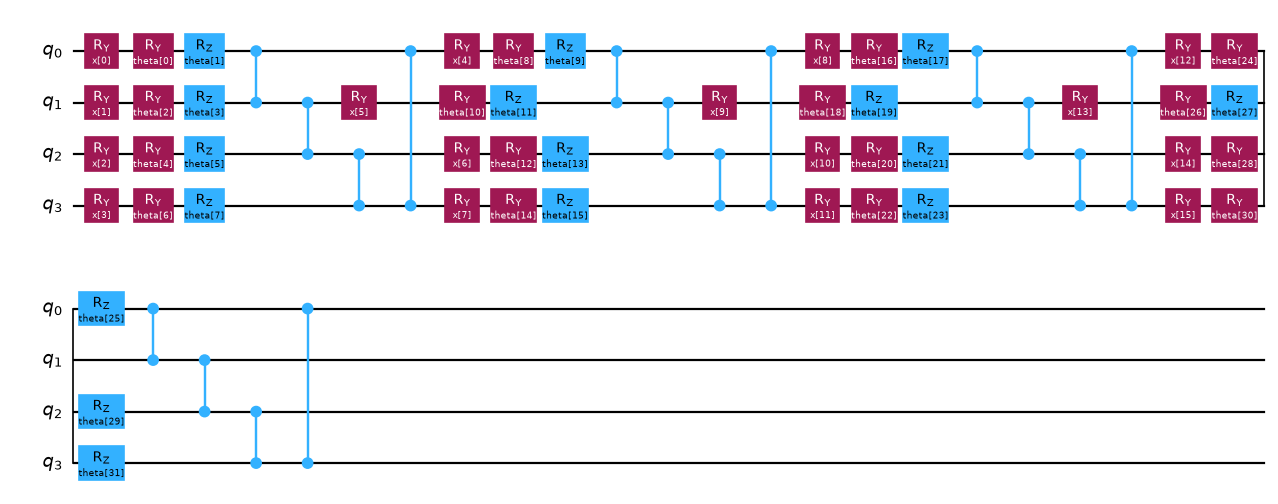

In [2]:
from traqmania.agents.quantum.circuit import build_circuit, circuit_spec

qc = build_circuit(n_qubits=4, n_layers=4)
spec = circuit_spec({"n_qubits": 4, "n_layers": 4})
print(f"gates: {spec['counts']['total']}  |  trainable parameters: {spec['n_params']}")
qc.draw("mpl", fold=23, scale=0.8)

The `x[l*4+i]` angles are the encoding inputs $\lambda_{l,i} s_i$ (the product
is computed outside the circuit, which keeps $\lambda$ trainable while the
circuit stays linear in the bound angle).

## Why re-uploading? Expressivity

A circuit that encodes the input once can only produce a *single-frequency*
sinusoid in each input feature. Each re-upload adds frequencies — the output
becomes a truncated Fourier series whose degree grows with $L$
([Pérez-Salinas et al. 2020](https://quantum-journal.org/papers/q-2020-02-06-226/)).
Let's sweep one input feature (the forward lidar ray) through its range and
watch $\langle Z_1 \rangle$ for circuits with $L = 1, 2, 4$ (random angles):

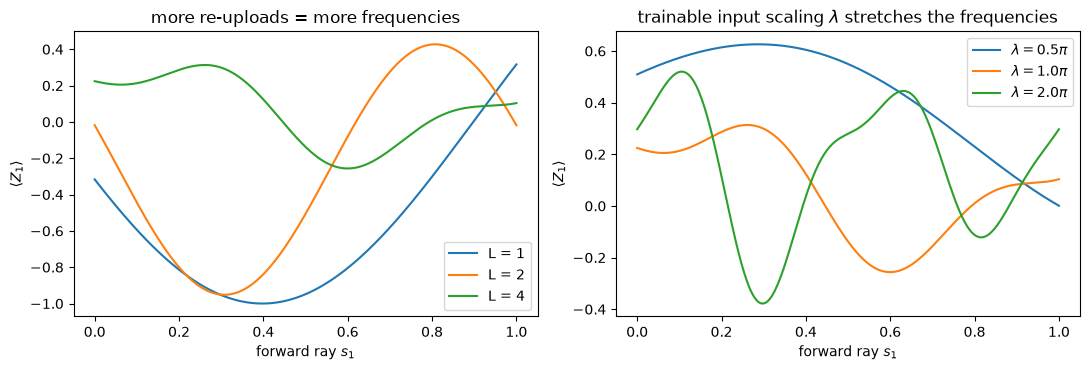

In [3]:
from traqmania.agents.quantum import QuantumQFunction

front = np.linspace(0.0, 1.0, 301)
base_obs = np.array([0.55, 0.0, 0.55, 0.6])  # feature 1 (forward ray) is swept

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
for n_layers in (1, 2, 4):
    qf = QuantumQFunction({"n_qubits": 4, "n_layers": n_layers, "seed": 7})
    qf.theta = np.random.default_rng(3).uniform(-np.pi, np.pi, qf.theta.shape)
    obs = np.tile(base_obs, (front.size, 1))
    obs[:, 1] = front
    ax1.plot(front, qf.expectations(obs)[:, 1], label=f"L = {n_layers}")
ax1.set(xlabel="forward ray $s_1$", ylabel=r"$\langle Z_1 \rangle$",
        title="more re-uploads = more frequencies")
ax1.legend()

qf = QuantumQFunction({"n_qubits": 4, "n_layers": 4, "seed": 7})
qf.theta = np.random.default_rng(3).uniform(-np.pi, np.pi, qf.theta.shape)
for scale in (0.5, 1.0, 2.0):
    qf.lam = np.full(qf.lam.shape, scale * np.pi)
    obs = np.tile(base_obs, (front.size, 1))
    obs[:, 1] = front
    ax2.plot(front, qf.expectations(obs)[:, 1], label=rf"$\lambda = {scale}\pi$")
ax2.set(xlabel="forward ray $s_1$", ylabel=r"$\langle Z_1 \rangle$",
        title=r"trainable input scaling $\lambda$ stretches the frequencies")
ax2.legend()
plt.tight_layout()
plt.show()

Left: with one encoding layer the response is a plain sinusoid; four re-uploads
give a much richer function class. Right: the trainable scales $\lambda$ let
the optimizer choose *which* frequencies to use — the network can sharpen or
flatten its response to each lidar ray.

## Two implementations, one circuit

traQmania has two interchangeable executions of this exact circuit:

- **`fastsim`** — a hand-written numpy statevector simulator with adjoint
  (backpropagation-style) gradients, used for training;
- **`QiskitQFunction`** — the same circuit through Qiskit /
  qiskit-machine-learning's `EstimatorQNN` on Aer, used to validate the fast
  path and to run with shots, noise, and eventually real hardware.

They must agree to numerical precision — let's check that, not assume it:

In [4]:
from traqmania.agents.quantum import make_qfunction

circuit_cfg = {"n_qubits": 4, "n_layers": 4}
fast = QuantumQFunction(circuit_cfg, seed=7)
qnn = make_qfunction("aer_statevector", circuit_cfg, seed=7)  # EstimatorQNN on Aer

obs = np.random.default_rng(1).uniform(0.0, 1.0, size=(8, 4))
diff = np.abs(fast.q_values(obs) - qnn.q_values(obs)).max()
print(f"max |fastsim - EstimatorQNN| over a random batch: {diff:.2e}")
assert diff < 1e-9

max |fastsim - EstimatorQNN| over a random batch: 1.11e-15


## Parameter budget: quantum vs classical

The quantum Q-function has $\lambda$ (16) + $\theta$ (32) + output head
$w, b$ (8) = **56 parameters** — deliberately in the same class as the
76-parameter MLP baseline, so later comparisons are parameter-for-parameter
honest.

In [5]:
from traqmania.agents.classical import MLPQFunction

mlp = MLPQFunction(n_features=4, hidden=8, n_actions=4, seed=0)
print(f"{'':14}{'quantum VQC':>14}{'classical MLP':>16}")
print(f"{'inputs':14}{4:>14}{4:>16}")
print(f"{'outputs':14}{4:>14}{4:>16}")
print(f"{'parameters':14}{fast.n_params:>14}{mlp.n_params:>16}")
print(f"  quantum: lam {fast.lam.size} + theta {fast.theta.size} "
      f"+ w {fast.w.size} + b {fast.b.size}")
print(f"  MLP:     W1 {mlp.W1.size} + b1 {mlp.b1.size} + W2 {mlp.W2.size} + b2 {mlp.b2.size}")

                 quantum VQC   classical MLP
inputs                     4               4
outputs                    4               4
parameters                56              76
  quantum: lam 16 + theta 32 + w 4 + b 4
  MLP:     W1 32 + b1 8 + W2 32 + b2 4


## A teaching point: the provably dead parameters

Look back at the circuit: in the **last block**, each qubit's $RZ$ gate is
followed only by *diagonal* operations — the CZ ring — before the $Z$
measurement. An $RZ$ rotation is itself diagonal, so it **commutes with
everything between it and the observable**: it merely shifts phases that a $Z$
measurement can never see. Its gradient is therefore *exactly zero* for every
input, not just small — those 4 parameters (of the 56) can never train.

Don't take the commutator argument on faith; take the derivative:

In [6]:
rng = np.random.default_rng(2)
obs = rng.uniform(0.0, 1.0, size=(64, 4))
actions = rng.integers(0, 4, size=64)
upstream = rng.normal(size=64)

grad = fast.grad_selected(obs, actions, upstream)      # (56,) flat gradient
dtheta = grad[16:48].reshape(4, 4, 2)                  # (layer, qubit, RY/RZ)

print(f"{'layer':>6}{'max |dL/dRY|':>16}{'max |dL/dRZ|':>16}")
for layer in range(4):
    print(f"{layer:>6}{np.abs(dtheta[layer, :, 0]).max():>16.3e}"
          f"{np.abs(dtheta[layer, :, 1]).max():>16.3e}")
assert np.abs(dtheta[-1, :, 1]).max() < 1e-12, "final-layer RZ should be gradient-dead"
print("\nfinal-layer RZ gradients are exactly zero -- 4 of the 56 parameters are dead weight.")

 layer    max |dL/dRY|    max |dL/dRZ|
     0       5.652e+00       7.403e-01
     1       5.527e+00       5.317e-01
     2       3.641e+00       3.434e-01
     3       2.180e+00       1.205e-17

final-layer RZ gradients are exactly zero -- 4 of the 56 parameters are dead weight.


This is a miniature of a very real phenomenon in variational algorithm design:
ansatz structure interacts with the observable, and parameters can silently do
nothing. (A cheap fix would be to drop the final RZ sublayer or measure
non-diagonal observables; we keep it as the canonical Chen/Skolik-style block
structure — and as a lesson.)

## What gradients cost: param-shift vs adjoint

`EstimatorQNN` computes gradients by the **parameter-shift rule**: two extra
circuit evaluations *per parameter* (2 × 48 circuit parameters, per sample,
per observable). The numpy fast path uses an **adjoint** method — one forward
plus one backward sweep of the statevector for the whole gradient, like
backprop. Same numbers, wildly different cost. Measure it on a small batch:

In [7]:
import time

obs8 = rng.uniform(0.0, 1.0, size=(8, 4))
act8 = rng.integers(0, 4, size=8)
up8 = rng.normal(size=8)

reps = 20
t0 = time.perf_counter()
for _ in range(reps):
    g_fast = fast.grad_selected(obs8, act8, up8)
t_adjoint = (time.perf_counter() - t0) / reps

t0 = time.perf_counter()
g_shift = qnn.grad_selected(obs8, act8, up8)  # param-shift through EstimatorQNN
t_shift = time.perf_counter() - t0

print(f"gradient agreement: max |diff| = {np.abs(g_fast - g_shift).max():.2e}")
print(f"adjoint (fastsim):        {t_adjoint * 1e3:8.1f} ms per batch-8 gradient")
print(f"param-shift (EstimatorQNN): {t_shift:6.1f} s  per batch-8 gradient")
print(f"speedup: ~{t_shift / t_adjoint:,.0f}x")

gradient agreement: max |diff| = 1.89e-15
adjoint (fastsim):             1.8 ms per batch-8 gradient
param-shift (EstimatorQNN):    6.4 s  per batch-8 gradient
speedup: ~3,534x


Identical gradients, three-to-four orders of magnitude apart in cost (on the
full batch-32 double-DQN update the measured gap is **~3.4 ms vs ~20.5 s, about
6000×**). This is *the* practical reason quantum RL research trains on
simulators: a DQN run takes tens of thousands of gradient steps, and
param-shift pricing turns seconds into weeks — before adding hardware queue
time. We return to this trade-off in [notebook 05](05_real_quantum_hardware.ipynb).


## Scaling to 6 qubits

Nothing above is specific to four qubits: `build_circuit(n_qubits)` produces
the same block structure at any width, and the observation grows with it — at
$n$ qubits the car gets $n - 1$ lidar rays, evenly spaced over
$[-60^\circ, +60^\circ]$, plus normalized speed: one feature per qubit. The **actions
stay 4** — readout is still $Z_0 \dots Z_3$ on the first four qubits, so extra
qubits only widen the feature register. The parameter count is
$P = 3Ln + 8$: 56 at $n = 4$, **80** at $n = 6$.


gates: 96  |  trainable parameters: {'lam': 24, 'theta': 48, 'w': 4, 'b': 4, 'total': 80}


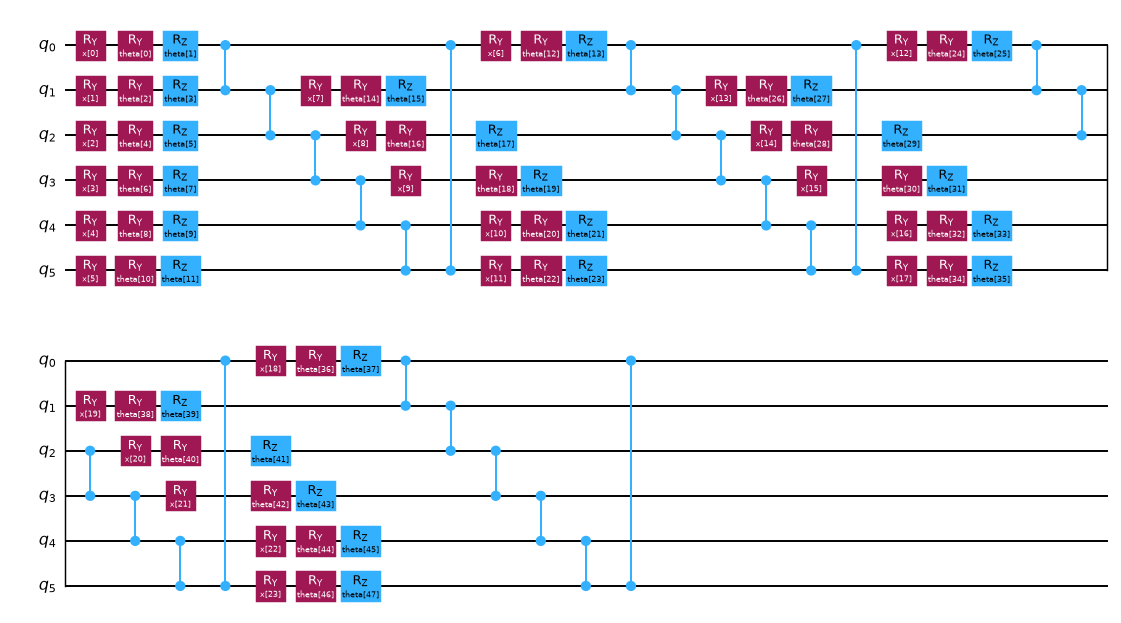

In [8]:
qc6 = build_circuit(n_qubits=6, n_layers=4)
spec6 = circuit_spec({"n_qubits": 6, "n_layers": 4})
print(f"gates: {spec6['counts']['total']}  |  trainable parameters: {spec6['n_params']}")
qc6.draw("mpl", fold=23, scale=0.7)


Both implementations execute this wider circuit too, and must still agree to
numerical precision — this time on fully random parameters (the test suite
pins the same check at $\le 10^{-9}$ and verifies all 80 gradient components
against finite differences). And the dead-parameter teaching point above is
$n$-independent: a final-layer $RZ$ commutes with everything between it and
the $Z$ readout at *any* width. At $n > 4$ there is a twist on top — qubits 4
and 5 are never measured, so their final-layer $RY$ angles are gradient-dead
too:


In [9]:
circuit_cfg6 = {"n_qubits": 6, "n_layers": 4}
fast6 = QuantumQFunction(circuit_cfg6, seed=7)
qnn6 = make_qfunction("aer_statevector", circuit_cfg6, seed=7)

rng6 = np.random.default_rng(6)
params6 = rng6.uniform(-np.pi, np.pi, size=fast6.n_params)
fast6.set_params(params6)
qnn6.set_params(params6)

obs6 = rng6.uniform(0.0, 1.0, size=(8, 6))
diff6 = np.abs(fast6.q_values(obs6) - qnn6.q_values(obs6)).max()
print(f"max |fastsim - EstimatorQNN| at 6 qubits, random params: {diff6:.2e}")
assert diff6 < 1e-9

grad6 = fast6.grad_selected(rng6.uniform(0.0, 1.0, size=(64, 6)),
                            rng6.integers(0, 4, size=64), rng6.normal(size=64))
dtheta6 = grad6[24:72].reshape(4, 6, 2)                # (layer, qubit, RY/RZ)
print(f"final-layer max |dL/dRZ|:    {np.abs(dtheta6[-1, :, 1]).max():.1e}  (dead at any n)")
print("final-layer |dL/dRY| per qubit:",
      np.array2string(np.abs(dtheta6[-1, :, 0]), precision=3))
assert np.abs(dtheta6[-1, :, 1]).max() < 1e-12         # RZ: dead on every qubit
assert np.abs(dtheta6[-1, 4:, 0]).max() < 1e-12        # RY: dead on the unread qubits


max |fastsim - EstimatorQNN| at 6 qubits, random params: 8.88e-16
final-layer max |dL/dRZ|:    3.8e-17  (dead at any n)
final-layer |dL/dRY| per qubit: [2.506 0.214 0.104 0.116 0.    0.   ]


The repository ships trained 6-qubit oval weights —
`traqmania/weights/quantum_oval_q6.npz`, seed 42, 600 episodes (how that run
compares against 4 qubits is
[notebook 04](04_training_the_quantum_driver.ipynb)'s job). Weight files
follow the rule `quantum_{track}[_warmstart|_stageN][_q{n}].npz`, with the
`_q{n}` tag omitted at the default 4 qubits, so profile runs never clobber the
bundled 4-qubit weights. Everything is wired together by the `q6` config
profile — the same overlay the live server (`./run.sh --profile q6`) and the
hardware CLI (`python -m traqmania.hardware lap --fake --profile q6`) use.
Load the weights and watch the Q-values pick actions around a lap:


In [10]:
from traqmania.config import load_config
from traqmania.env.racing_env import RacingEnv
from traqmania.env.track import Track
from traqmania.server.session import quantum_weights_path

config6 = load_config("q6")
print("q6 profile rays (deg):", config6["observation"]["ray_angles_deg"])

qf6 = QuantumQFunction(config6["circuit"])
weights_path = quantum_weights_path("oval", qf6.n_qubits)
qf6.set_params(np.load(weights_path)["params"])
print(f"loaded {weights_path.name}: {qf6.n_params} params\n")

env6 = RacingEnv(Track.load("oval"), config6, n_envs=1, seed=3)
obs = env6.reset()
names = ("steer left", "straight", "steer right", "brake")
print(f"{'obs = [rays -60 -30 0 +30 +60 deg, speed]':<46}"
      + "".join(f"{n:>12}" for n in names))
for step in range(200):
    q = qf6.q_values(obs)
    if step % 30 == 0:
        row = "  ".join(f"{v:.2f}" for v in obs[0])
        print(f"t={step / 10:5.1f}s  [{row}]"
              + "".join(f"{v:>12.1f}" for v in q[0]) + f"  -> {names[q[0].argmax()]}")
    obs, _reward, _done, info = env6.step(np.argmax(q, axis=1))
    if info["lap"][0] >= 1:
        print(f"\nclean lap in {info['last_lap_time'][0]:.1f} s from a standing start "
              f"(off track: {bool(info['off_track'][0])})")
        break


q6 profile rays (deg): [-60.0, -30.0, 0.0, 30.0, 60.0]
loaded quantum_oval_q6.npz: 80 params

obs = [rays -60 -30 0 +30 +60 deg, speed]       steer left    straight steer right       brake
t=  0.0s  [0.21  0.34  1.00  0.61  0.33  0.00]        84.7        86.0        86.1        84.5  -> steer right
t=  3.0s  [0.21  0.35  1.00  0.59  0.33  0.76]        85.8        86.2        85.7        84.9  -> straight
t=  6.0s  [0.32  0.55  1.00  0.35  0.24  1.00]        86.4        87.0        77.9        82.3  -> straight
t=  9.0s  [0.37  0.52  1.00  0.39  0.16  1.00]        84.5        87.6        79.4        82.7  -> straight
t= 12.0s  [0.21  0.35  1.00  0.61  0.33  1.00]        85.9        86.1        86.1        84.9  -> steer right
t= 15.0s  [0.33  0.46  0.77  1.00  0.21  1.00]        85.3        86.1        86.2        83.1  -> steer right

clean lap in 16.7 s from a standing start (off track: False)


The `q8` / `q10` profiles extend the same recipe to 7 and 9 rays. They are
**untrained options**: the config overlays exist, but no weights are bundled —
training runs at those widths are yours to do. The default stays 4 qubits, and
a regression test pins the bundled 4-qubit weights' Q-values so the scaling
machinery cannot silently change them.

**Next:** [04 — Training the quantum driver](04_training_the_quantum_driver.ipynb)
plugs this circuit into the DQN loop from notebook 02 and races it against the
MLP — including a 4-vs-6-qubit comparison.